In [ ]:
#!pip install yfinance
# Thêm các thư viện cần thiết
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from tensorflow.keras.models import Model
from keras.layers import LSTM, Dense, Bidirectional, Dropout, Input, Concatenate
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import History
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation
from keras.layers import Conv1D, MaxPooling1D, Flatten, AveragePooling1D
!pip install keras-self-attention
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.layers import MultiHeadAttention
!pip install attention
from attention import Attention

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18894 sha256=05ec4d39734de0188e7f23881c26b231a866f97c63f77b5036dd529937c32508
  Stored in directory: /root/.cache/pip/wheels/b8/f7/24/607b483144fb9c47b4ba2c5fba6b68e54aeee2d5bf6c05302e
Successfully built keras-self-attention


In [ ]:
data_ORCL = pd.read_csv('ORCL.csv')

data_ORCL

,Date,Close,Open,High,Low,Adj Close,Volume
0,2019-12-31,52.980000,52.570000,53.000000,52.549999,49.155796,7094500
1,2020-01-02,53.950001,53.270000,53.959999,53.230000,50.055779,13899600
2,2020-01-03,53.759998,52.990002,54.049999,52.950001,49.879490,11026700
3,2020-01-06,54.040001,53.360001,54.200001,53.349998,50.139278,10982400
4,2020-01-07,54.160000,53.889999,54.330002,53.610001,50.250622,12015400
...,...,...,...,...,...,...,...
1105,2024-05-22,124.599998,124.629997,125.160004,123.300003,124.249191,5705000
1106,2024-05-23,124.089996,126.550003,126.699997,123.160004,123.740623,6108600
1107,2024-05-24,122.910004,123.419998,123.510002,121.419998,122.563950,7166100
1108,2024-05-28,124.489998,123.239998,124.820000,123.010002,124.139496,6911400


In [ ]:
data = data_ORCL
epoch = 500
#columns = ['Close']
columns = ['Close', 'Open', 'High', 'Low']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume']
#columns = ['Close', 'Open', 'High', 'Low']
#columns = ['Close', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI', 'Broad money M2']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI']

data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]

train = train[columns]

scaler = MinMaxScaler(feature_range = (0, 1))

# train_scaled = scaler.fit_transform(train)
# test_scaled = scaler.transform(data)
scaled = scaler.fit_transform(data)
train_scaled = scaled[:int(train_size)]

test_data_lb_7day = scaled[int(train_size) - 7: , :]
test_data_lb_14day = scaled[int(train_size) - 14: , :]
test_data_lb_21day = scaled[int(train_size) - 21: , :]

In [ ]:
def create_cnn_lstm_branch(input_layer, units, dropout_rate):
    cnn = Conv1D(filters=64, kernel_size=3, padding = 'same', activation='relu')(input_layer)
    cnn = Conv1D(filters=128, kernel_size=3, padding = 'same', activation='relu')(cnn)
    #cnn = Conv1D(filters=128, kernel_size=3, padding = 'same', activation='relu')(cnn)
    cnn = Conv1D(filters=64, kernel_size=3, padding = 'same', activation='relu')(cnn)
    #cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = AveragePooling1D(pool_size=2)(cnn)

    lstm = LSTM(units=units, return_sequences=True)(cnn)


    #lstm = SeqSelfAttention(attention_activation='elu')(lstm)
    lstm = Attention(units=units)(lstm)

    #lstm = Flatten()(lstm)

    return lstm

def parallel_cnn_lstm_model(train_scaled, test_scaled, lb, batchsize):
    X_train = []
    Y_train = []

    for i in range(lb, len(train_scaled)):
        X_train.append(train_scaled[i - lb:i, :])
        Y_train.append(train_scaled[i, 0])

    X_train, Y_train = np.array(X_train), np.array(Y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(columns)))
    x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size=0.1)

    start_time = time.time()
    history = History()
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    input_layer = Input(shape=(x_train.shape[1], x_train.shape[2]))

    cnn_lstm1 = create_cnn_lstm_branch(input_layer, units=128, dropout_rate=0.3)
    cnn_lstm2 = create_cnn_lstm_branch(input_layer, units=128, dropout_rate=0.3)
    concatenated = Concatenate()([cnn_lstm1, cnn_lstm2])

    concatenated = Flatten()(concatenated)

    dense = Dense(units=128, activation='sigmoid')(concatenated)
    output = Dense(units=1)(dense)

    model = Model(inputs=input_layer, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mse')
    # Train the model
    model.fit(x_train, y_train, epochs=epoch, validation_data=(x_val, y_val),
              batch_size=batchsize, callbacks=[history, early_stopping])

    end_time = time.time()
    training_time = end_time - start_time

    loss = history.history['loss']
    val_loss = history.history['val_loss']
    plt.plot(loss)
    plt.plot(val_loss)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc = 'upper right')
    plt.show()

    x_test = []
    for i in range(lb, len(test_scaled)):
      x_test.append(test_scaled[i - lb:i, :])
    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], len(columns)))

    predictions = model.predict(x_test)
    predictions = predictions.reshape(-1, 1)
    X = np.random.rand(int(len(test)), int(len(columns) - 1))
    predictions = np.hstack((predictions, X))
    predictions = scaler.inverse_transform(predictions)

    return predictions[:, 0], training_time

Epoch 1/500
14/14 [==============================] - 7s 114ms/step - loss: 0.0190 - val_loss: 0.0071
Epoch 2/500
14/14 [==============================] - 0s 18ms/step - loss: 0.0054 - val_loss: 0.0019
Epoch 3/500
14/14 [==============================] - 0s 22ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 4/500
14/14 [==============================] - 0s 12ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 5/500
14/14 [==============================] - 0s 13ms/step - loss: 0.0010 - val_loss: 0.0010
Epoch 6/500
14/14 [==============================] - 0s 13ms/step - loss: 9.8880e-04 - val_loss: 0.0012
Epoch 7/500
14/14 [==============================] - 0s 11ms/step - loss: 9.5954e-04 - val_loss: 0.0013
Epoch 8/500
14/14 [==============================] - 0s 12ms/step - loss: 9.3341e-04 - val_loss: 0.0010
Epoch 9/500
14/14 [==============================] - 0s 13ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 10/500
14/14 [==============================] - 0s 12ms/step - loss: 9.9771e-04 -

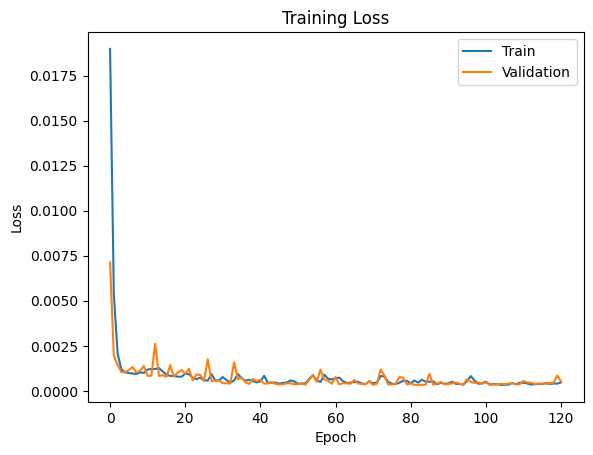

4/4 [==============================] - 1s 7ms/step


In [ ]:
predictions_lb_7day, training_time_lb_7day = parallel_cnn_lstm_model(train_scaled, test_data_lb_7day, 7, 64)

Epoch 1/500
10/10 [==============================] - 6s 108ms/step - loss: 0.0469 - val_loss: 0.0254
Epoch 2/500
10/10 [==============================] - 0s 15ms/step - loss: 0.0113 - val_loss: 0.0085
Epoch 3/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0055 - val_loss: 0.0016
Epoch 4/500
10/10 [==============================] - 0s 14ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 5/500
10/10 [==============================] - 0s 16ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 6/500
10/10 [==============================] - 0s 17ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 7/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 8/500
10/10 [==============================] - 0s 13ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 9/500
10/10 [==============================] - 0s 14ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 10/500
10/10 [==============================] - 0s 14ms/step - loss: 0.0013 - val_loss: 0.001

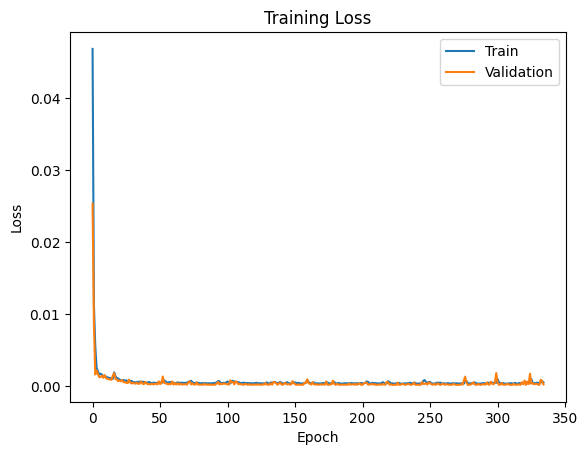

4/4 [==============================] - 1s 6ms/step


In [ ]:
predictions_lb_14day, training_time_lb_14day = parallel_cnn_lstm_model(train_scaled, test_data_lb_14day, 14, 96)

Epoch 1/500
7/7 [==============================] - 7s 153ms/step - loss: 0.1341 - val_loss: 0.0110
Epoch 2/500
7/7 [==============================] - 0s 16ms/step - loss: 0.0231 - val_loss: 0.0210
Epoch 3/500
7/7 [==============================] - 0s 14ms/step - loss: 0.0214 - val_loss: 0.0231
Epoch 4/500
7/7 [==============================] - 0s 14ms/step - loss: 0.0164 - val_loss: 0.0118
Epoch 5/500
7/7 [==============================] - 0s 15ms/step - loss: 0.0083 - val_loss: 0.0045
Epoch 6/500
7/7 [==============================] - 0s 15ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 7/500
7/7 [==============================] - 0s 13ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 8/500
7/7 [==============================] - 0s 13ms/step - loss: 0.0024 - val_loss: 0.0028
Epoch 9/500
7/7 [==============================] - 0s 15ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 10/500
7/7 [==============================] - 0s 14ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 11/500
7/7 [

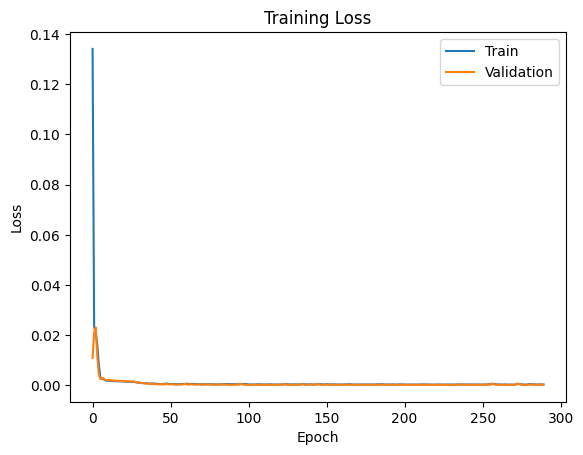

4/4 [==============================] - 1s 5ms/step


In [ ]:
predictions_lb_21day, training_time_lb_21day = parallel_cnn_lstm_model(train_scaled, test_data_lb_21day, 21, 128)

In [ ]:
data_visual = data_ORCL.filter(['Date', 'Close'])
data_visual['Date'] = pd.to_datetime(data_visual['Date'])
valid = data_visual[train_size:]

valid['Predictions lb 7 day'] = predictions_lb_7day
valid['Predictions lb 14 day'] = predictions_lb_14day
valid['Predictions lb 21 day'] = predictions_lb_21day

valid

<ipython-input-169-33984e91cc03>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 7 day'] = predictions_lb_7day
<ipython-input-169-33984e91cc03>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 14 day'] = predictions_lb_14day
<ipython-input-169-33984e91cc03>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

,Date,Close,Predictions lb 7 day,Predictions lb 14 day,Predictions lb 21 day
999,2023-12-19,106.250000,105.480014,105.148850,105.622742
1000,2023-12-20,104.150002,106.461736,105.374870,105.615129
1001,2023-12-21,105.860001,105.396205,104.091108,104.150837
1002,2023-12-22,106.199997,105.438635,105.671441,105.794748
1003,2023-12-26,106.190002,106.315900,106.050761,106.341958
...,...,...,...,...,...
1105,2024-05-22,124.599998,124.292193,123.713855,124.039773
1106,2024-05-23,124.089996,124.025006,123.477018,123.686155
1107,2024-05-24,122.910004,124.225651,123.638282,123.806567
1108,2024-05-28,124.489998,122.551822,122.197942,121.838054


In [ ]:
def calculateAccurary(prediction, close):

  mse = mean_squared_error(close, prediction)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(close, prediction)
  mape = mean_absolute_percentage_error(close, prediction)
  r2 = r2_score(close, prediction)

  print("RMSE:", round(rmse, 5))
  print("MSE :", round(mse, 5))
  print("MAE :", round(mae, 5))
  print("MAPE:", round(mape, 5))
  print("R^2 :", round(r2, 5))
  print()

print("CNN-LSTM Lb 7 day")
print("Training time CNN-LSTM:", round(training_time_lb_7day, 2), "seconds", "=", round(training_time_lb_7day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 7 day'], valid["Close"])

print("CNN-LSTM Lb 14 day")
print("Training time CNN-LSTM:", round(training_time_lb_14day, 2), "seconds", "=", round(training_time_lb_14day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 14 day'], valid["Close"])

print("CNN-LSTM Lb 21 day")
print("Training time CNN-LSTM:", round(training_time_lb_21day, 2), "seconds", "=", round(training_time_lb_21day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 21 day'], valid["Close"])

CNN-LSTM Lb 7 day
Training time CNN-LSTM: 30.12 seconds = 0.5 minutes
RMSE: 2.03165
MSE : 4.12759
MAE : 1.29718
MAPE: 0.01112
R^2 : 0.92099

CNN-LSTM Lb 14 day
Training time CNN-LSTM: 58.2 seconds = 0.97 minutes
RMSE: 1.98989
MSE : 3.95965
MAE : 1.26431
MAPE: 0.01081
R^2 : 0.9242

CNN-LSTM Lb 21 day
Training time CNN-LSTM: 41.5 seconds = 0.69 minutes
RMSE: 1.985
MSE : 3.94022
MAE : 1.25928
MAPE: 0.01075
R^2 : 0.92457



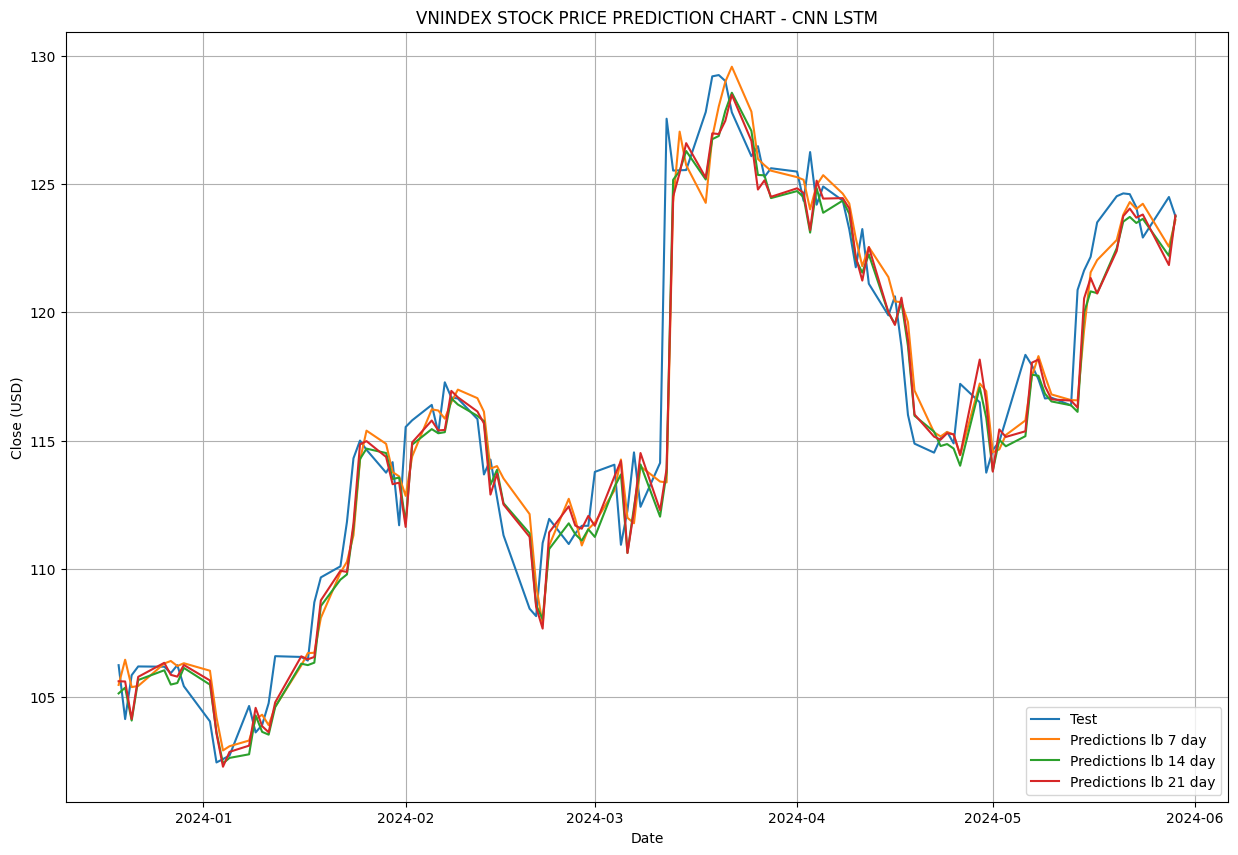

In [ ]:
# Draw a historial of closing price
plt.figure(figsize=(15, 10))

plt.plot(valid['Date'], valid['Close'])
plt.plot(valid['Date'], valid['Pre`dictions lb 7 day'])
plt.plot(valid['Date'], valid['Predictions lb 14 day'])
plt.plot(valid['Date'], valid['Predictions lb 21 day'])
plt.ylabel('Close (USD)', fontsize=16)
plt.ylabel('Close (USD)', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.title(f"ORCL STOCK PRICE PREDICTION CHART - PARALLEL CNN-LSTM-ATTENTION", fontsize=18)
plt.legend(['Actual Closing Price', 'Predicted Closing Price - Lookback  7 days',
            'Predicted Closing Price - Lookback 14 days', 'Predicted Closing Price - Lookback 21 days'], loc='lower right', fontsize=14)
plt.grid(True)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()
